In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../src/FluoreModel/')

In [3]:
def create_sampler_by_brightness_quantiles(df, brightness_col='Brightness', n_quantiles=5):
    """
    Создает семплер, где вес зависит от квантиля яркости.
    Более яркие (или редкие) образцы получают больший вес.
    """
    
    # Разбиваем на квантили
    df['brightness_quantile'] = pd.qcut(
        df[brightness_col], 
        q=n_quantiles, 
        labels=False, 
        duplicates='drop'
    )
    
    # Считаем количество в каждом квантиле
    quantile_counts = df['brightness_quantile'].value_counts().sort_index()
    
    # Вес для каждого квантиля: обратно пропорционален частоте
    quantile_weights = 1.0 / quantile_counts 
    quantile_weights = quantile_weights / quantile_weights.sum()  # Нормализация
    
    # Присваиваем вес каждому образцу
    df['sample_weight'] = df['brightness_quantile'].map(quantile_weights)
    
    return df

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler
from functools import partial
from transformers import AutoTokenizer, AutoModel
from torch import nn
import torch


import model
from gfp_datasets import SimpleDataset, collate_fn
import train_utils



BATCH_SIZE = 550
ESM_TYPE = "facebook/esm2_t36_3B_UR50D"


# mutations_df = pd.read_csv("../data/rel_brightness/data.csv")
# mutations_df.Brightness = mutations_df.rel_brightness.astype('float32')


train_df = pd.read_csv("../data/rel_brightness_top/train.csv")
# X = create_sampler_by_brightness_quantiles(train_df, n_quantiles=3)
# sampler = create_sampler_by_brightness_quantiles(X['sample_weight'], len(X['sample_weight']))

X_train = train_df['seq']
y_train = train_df['rel_brightness']

val_df = pd.read_csv("../data/rel_brightness_top/val.csv")
X_val = val_df['seq']
y_val = val_df['rel_brightness']


tokenizer = AutoTokenizer.from_pretrained(ESM_TYPE, return_tensors='pt', padding=True, truncation=True)
my_collate_fn = partial(collate_fn, tokenizer=tokenizer)    

train_dataset = SimpleDataset(X_train.to_numpy(), y_train.to_numpy())
val_dataset = SimpleDataset(X_val.to_numpy(), y_val.to_numpy())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=my_collate_fn, num_workers=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=my_collate_fn, num_workers=4)

/trinity/home/d_ryabov/.conda/envs/newNucDPosIT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# hidden_dim = [1280, 512, 256, 256, 128, 128, 128, 128, 128, 128, 64, 64, 64, 64, 64, 64, 64, 64, 32, 32, 32, 32, 32, 32, 32, 32, 16, 16, 16, 16, 16, 8, 8, 8, 8, 4, 4, 4, 4, 2, 2, 2, 2]
# hidden_dim = [1280, 2056, 4000, 6000, 4090, 2056, 1024, 512, 256, 256, 256, 128, 128, 128, 64, 64, 64, 32, 32, 32, 32, 16, 16, 16, 8, 8, 4, 4, 2, 2]
model = model.GFPRegressionModel(2560, device='cuda', freeze_esm=True, esm_model_name=ESM_TYPE)

if torch.cuda.device_count() > 1:
    print(f"Используем {torch.cuda.device_count()} GPU!")
    model = nn.DataParallel(model) 

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 25.02it/s]
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Режим: ESM-2 заморожен


In [ ]:
model = model.train()


train_utils.train_model(
    model, train_loader, None, save_path="../data/best_models/gfp3_best.pt", epochs=1, lr=0.001 / 2
)

/trinity/home/d_ryabov/.conda/envs/newNucDPosIT/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



📊 TensorBoard logs: ../logs/tensorboard/20260622_013006
🚀 Запустите: tensorboard --logdir=../logs/tensorboard


НАЧАЛО ОБУЧЕНИЯ
Устройство: cuda
Эпох: 1
Learning rate: 0.0005
Weight decay: 0.0001
Patience: 15



Training:   0%|          | 0/56 [00:00<?, ?it/s]/trinity/home/d_ryabov/.conda/envs/newNucDPosIT/lib/python3.11/site-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([300])) that is different to the input size (torch.Size([300, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
Training:   4%|▎         | 2/56 [00:49<22:24, 24.89s/it, loss=140]  

In [40]:
model = model.eval()

In [41]:
train_loader = DataLoader(val_dataset, batch_size=300, collate_fn=my_collate_fn, num_workers=4, shuffle=True)

In [42]:
iterator = iter(train_loader)

In [43]:
torch.cuda.empty_cache()

In [49]:
val_data = next(iterator)

In [50]:
with torch.no_grad():
    val_res = model(val_data[0]).flatten()

In [51]:
val_res

tensor([ 0.3626, -0.1257, -0.3924, -0.2722,  0.0746, -0.0504, -0.1838,  0.0243,
         0.1375,  0.1633, -0.2477, -0.2101, -0.2796, -0.2371, -0.1443, -0.2400,
         0.0952, -0.1931, -0.2525, -0.6003, -0.1319, -0.1523, -0.2974, -0.2348,
        -0.2221,  0.0357,  0.3457, -0.0841,  0.0272, -0.2004, -0.1480, -0.3585,
        -0.1262, -0.0753,  0.3753, -0.1315,  0.0087, -0.3018,  0.3515, -0.5812,
        -0.1591,  0.1653,  0.2810,  0.1943, -0.2519, -0.1973, -0.3478, -0.6671,
        -0.2592, -0.1616, -0.1645, -0.2390,  0.3536,  0.2487,  0.2871, -0.1509,
        -0.2664, -0.1564,  0.1338, -0.0694, -0.3444, -0.1255, -0.1310,  0.1783,
        -0.1520,  0.3697, -0.1059, -0.2762, -0.3325, -0.2119, -0.1524,  0.0220,
         0.3536,  0.4612, -0.0813, -0.3228,  0.3569,  0.2059,  0.2654,  0.2987,
        -0.1828,  0.1024, -0.2456,  0.0484, -0.1339, -0.1600,  0.1208, -0.2601,
        -0.1470, -0.2080,  0.0503, -0.2764, -0.2023, -0.0079, -0.5715,  1.1316,
        -0.1690, -0.3622, -0.2631, -0.07

(-5.0, 5.0)

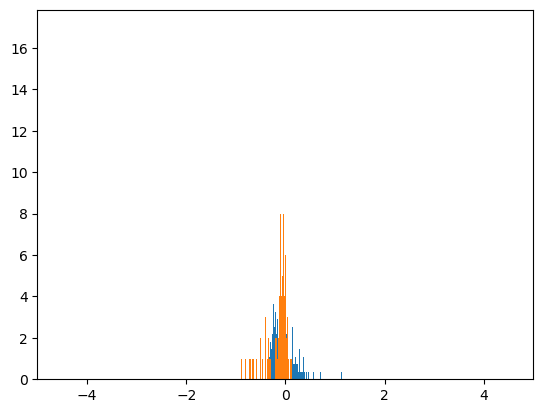

In [52]:
import matplotlib.pyplot as plt
import numpy as np

_ = plt.hist(val_res.cpu(), density=True, bins=200)
plt.hist(val_data[1], bins=200)
plt.xlim(-5, 5)

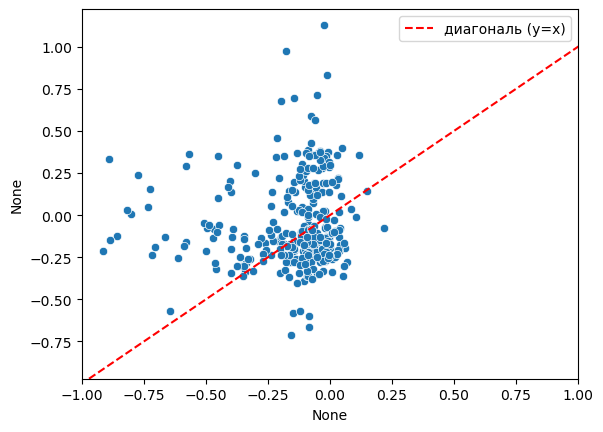

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ваш существующий код
sns.scatterplot(x=val_data[1].flatten(), y=val_res.cpu().flatten())

# Добавляем диагональ
# Определяем диапазон осей, чтобы линия проходила от min до max
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
# Берём общий диапазон, чтобы линия была ровно по углам
lims = [min(x_min, y_min), max(x_max, y_max)]
plt.plot(lims, lims, 'r--', label='диагональ (y=x)')  # красный пунктир

# (Опционально) установить одинаковые оси
plt.xlim(lims)
plt.ylim(lims)

plt.legend()
plt.xlim(-1, 1)
plt.show()